# Notebook 00: Load & Assign Real SRK Genotype Data

This notebook loads **revised** SRK (S-locus Receptor Kinase) genotyping data for **slickspot peppergrass** (*Lepidium papilliferum*), assigns tetraploid genotypes **without imputation**, and exports population data for downstream analysis.

## Key Improvement Over Previous Pipeline

The revised data includes a **zygosity file** that directly specifies each individual's genotype pattern (AAAA, AABB, AABC, or ABCD). Combined with the protein presence/absence matrix, this allows **deterministic genotype assignment** for all individuals. No imputation is needed.

## Data Sources (in `data/revised/`)

| File | Description |
|---|---|
| `SRK_individual_zygosity.tsv` | N_proteins, Zygosity, Genotype pattern (AAAA/AABB/AABC/ABCD) per individual |
| `SRK_individual_genotypes.tsv` | Binary presence/absence matrix (individuals x 94 SRK proteins) |
| `SRK_individual_protein_table.tsv` | Long-format read-level data (resolves AABC doubled allele) |
| `SRK_individual_status_report.tsv` | QC classification and filtering status per individual |
| `sampling_metadata.csv` | Population (Pop), Ingroup/Outgroup status, sample identifiers |

## Genotype Assignment Rules

Since *L. papilliferum* is tetraploid (4 allele copies per individual at the S-locus), each individual's genotype is a sorted tuple of 4 protein IDs.

| Pattern | N proteins | Rule | Ambiguity |
|---|---|---|---|
| AAAA | 1 | 4 copies of the single protein | None |
| AABB | 2 | 2 copies of each protein | None |
| ABCD | 4 | 1 copy of each protein | None |
| AABC | 3 | 1 protein doubled, other 2 single-copy; doubled = highest read count | Resolved by read depth |

In [1]:
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATA_DIR = os.path.join("..", "data")
REVISED_DIR = os.path.join(DATA_DIR, "revised")
print("Imports loaded.")

Imports loaded.


## 1. Load Revised Data Files

Load all five revised data files and display basic shape information.

In [2]:
# --- Load all five revised data files ---
zygosity_df = pd.read_csv(os.path.join(REVISED_DIR, "SRK_individual_zygosity.tsv"), sep="\t")
genotypes_df = pd.read_csv(os.path.join(REVISED_DIR, "SRK_individual_genotypes.tsv"), sep="\t")
protein_table = pd.read_csv(os.path.join(REVISED_DIR, "SRK_individual_protein_table.tsv"), sep="\t")
status_df = pd.read_csv(os.path.join(REVISED_DIR, "SRK_individual_status_report.tsv"), sep="\t")
metadata_df = pd.read_csv(os.path.join(REVISED_DIR, "sampling_metadata.csv"))

protein_columns = [c for c in genotypes_df.columns if c != "Individual"]

print("File shapes:")
print(f"  Zygosity:      {zygosity_df.shape[0]} individuals x {zygosity_df.shape[1]} columns")
print(f"  Genotypes:     {genotypes_df.shape[0]} individuals x {len(protein_columns)} proteins")
print(f"  Protein table: {protein_table.shape[0]} read rows")
print(f"  Status report: {status_df.shape[0]} individuals")
print(f"  Metadata:      {metadata_df.shape[0]} samples")

File shapes:
  Zygosity:      128 individuals x 4 columns
  Genotypes:     128 individuals x 94 proteins
  Protein table: 1079 read rows
  Status report: 154 individuals
  Metadata:      156 samples


## 2. Data Overview & Cross-Validation

Verify internal consistency across the data files before proceeding.

In [3]:
# --- Zygosity overview ---
print("=== Zygosity Distribution ===")
print(zygosity_df["Genotype"].value_counts().to_string())
print(f"Total: {len(zygosity_df)} individuals\n")

# --- Cross-validate: N_proteins in zygosity should match row sums in genotype matrix ---
geno_protein_counts = genotypes_df.set_index("Individual")[protein_columns].sum(axis=1).astype(int)
merged_check = zygosity_df.set_index("Individual")[["N_proteins"]].join(
    geno_protein_counts.rename("geno_count")
)
mismatches = merged_check[merged_check["N_proteins"] != merged_check["geno_count"]]

print("=== Cross-Validation: Zygosity vs Genotype Matrix ===")
if len(mismatches) == 0:
    print("PASS: N_proteins matches genotype presence count for all 128 individuals.")
else:
    print(f"FAIL: {len(mismatches)} mismatches found:")
    print(mismatches)

# --- Verify genotype matrix is binary ---
geno_values = genotypes_df[protein_columns].values
assert set(np.unique(geno_values)) <= {0, 1}, "Genotype matrix has non-binary values!"
print("PASS: All genotype matrix values are 0 or 1.")

# --- Verify individuals in zygosity match genotype matrix ---
zyg_ids = set(zygosity_df["Individual"])
geno_ids = set(genotypes_df["Individual"])
assert zyg_ids == geno_ids, f"Mismatch: {zyg_ids.symmetric_difference(geno_ids)}"
print(f"PASS: Same {len(zyg_ids)} individuals in zygosity and genotype files.\n")

# --- Status report overview ---
print("=== QC Status Report ===")
print(status_df["Classification"].value_counts().to_string())
print(f"\nIn final genotype data: {(status_df['In_final_genotype_data'] == 'Yes').sum()} / {len(status_df)}")

=== Zygosity Distribution ===
Genotype
AAAA    66
AABB    51
ABCD     6
AABC     5
Total: 128 individuals

=== Cross-Validation: Zygosity vs Genotype Matrix ===
PASS: N_proteins matches genotype presence count for all 128 individuals.
PASS: All genotype matrix values are 0 or 1.
PASS: Same 128 individuals in zygosity and genotype files.

=== QC Status Report ===
Classification
normal                      75
low_functional_rate         53
dropped_abundance_filter    21
no_functional_proteins       5

In final genotype data: 128 / 154


## 3. Filter to Ingroup Individuals

The metadata contains an `Ingroup` flag (1 = *L. papilliferum*, 0 = outgroup species like *L. montanum*, *L. freemontii*, *L. philonitron*). We exclude outgroup samples since they are not crossing candidates.

We also handle `SRK_BEA`, which appears in the genotype data but has no metadata entry.

In [4]:
# --- Identify outgroup and missing-metadata individuals ---
zyg_individuals = set(zygosity_df["Individual"])
meta_individuals = set(metadata_df["SampleID"])

# Individuals in genotype data but not in metadata
no_metadata = zyg_individuals - meta_individuals
print(f"Individuals with genotype data but no metadata: {no_metadata}")

# Outgroup individuals that have genotype data
outgroup_ids = set(metadata_df[metadata_df["Ingroup"] == 0]["SampleID"])
outgroup_with_data = outgroup_ids & zyg_individuals
print(f"\nOutgroup individuals with genotype data ({len(outgroup_with_data)}):")
if outgroup_with_data:
    out_meta = metadata_df[metadata_df["SampleID"].isin(outgroup_with_data)]
    print(out_meta[["SampleID", "EO_w_sub", "Individual"]].to_string(index=False))

# --- Build exclusion list ---
exclude_ids = outgroup_with_data | no_metadata
print(f"\nTotal excluded: {len(exclude_ids)} individuals")
print(f"  Outgroup: {len(outgroup_with_data)}")
print(f"  No metadata: {len(no_metadata)}")

# --- Filter all data frames ---
keep_mask_zyg = ~zygosity_df["Individual"].isin(exclude_ids)
keep_mask_geno = ~genotypes_df["Individual"].isin(exclude_ids)

zygosity_filtered = zygosity_df[keep_mask_zyg].copy().reset_index(drop=True)
genotypes_filtered = genotypes_df[keep_mask_geno].copy().reset_index(drop=True)

print(f"\nAfter filtering: {len(zygosity_filtered)} ingroup individuals with genotype data")
print(f"Genotype pattern distribution:")
print(zygosity_filtered["Genotype"].value_counts().to_string())

Individuals with genotype data but no metadata: {'SRK_BEA'}

Outgroup individuals with genotype data (3):
            SampleID    EO_w_sub Individual
Library002_barcode24    montanum   Garfield
Library002_barcode54    montanum      SB405
Library002_barcode56 philonitron      SB395

Total excluded: 4 individuals
  Outgroup: 3
  No metadata: 1

After filtering: 124 ingroup individuals with genotype data
Genotype pattern distribution:
Genotype
AAAA    64
AABB    49
ABCD     6
AABC     5


## 4. Assign Tetraploid Genotypes

For each individual, combine the **zygosity pattern** with the **detected proteins** to build the 4-allele genotype tuple. No imputation is needed.

### Assignment Logic

- **AAAA** (1 protein detected): `(P1, P1, P1, P1)` — homozygous at all 4 copies
- **AABB** (2 proteins detected): `(P1, P1, P2, P2)` — each protein has 2 copies
- **ABCD** (4 proteins detected): `(P1, P2, P3, P4)` — each protein has 1 copy
- **AABC** (3 proteins detected): `(Pmax, Pmax, Px, Py)` — the protein with the highest read count in the protein table gets 2 copies; the other two get 1 copy each

In [5]:
def assign_genotype(individual, genotype_pattern, detected_proteins, protein_reads):
    """Assign a tetraploid genotype from zygosity pattern and detected proteins.

    Parameters
    ----------
    individual : str
        Individual identifier.
    genotype_pattern : str
        One of 'AAAA', 'AABB', 'AABC', 'ABCD'.
    detected_proteins : list[str]
        Protein names detected for this individual (from genotype matrix).
    protein_reads : dict[str, int]
        Read counts per protein (from protein table).

    Returns
    -------
    tuple[str, ...]
        Sorted 4-element tuple of protein names.
    str
        Assignment method description.
    """
    proteins = sorted(detected_proteins)

    if genotype_pattern == "AAAA":
        assert len(proteins) == 1, f"{individual}: AAAA but {len(proteins)} proteins"
        return tuple(proteins * 4), "homozygous_4x"

    elif genotype_pattern == "AABB":
        assert len(proteins) == 2, f"{individual}: AABB but {len(proteins)} proteins"
        return tuple(sorted(proteins * 2)), "heterozygous_2x2"

    elif genotype_pattern == "ABCD":
        assert len(proteins) == 4, f"{individual}: ABCD but {len(proteins)} proteins"
        return tuple(proteins), "heterozygous_1x4"

    elif genotype_pattern == "AABC":
        assert len(proteins) == 3, f"{individual}: AABC but {len(proteins)} proteins"
        # Determine which protein is doubled using read depth
        read_counts = {p: protein_reads.get(p, 0) for p in proteins}
        # Sort by read count descending, then alphabetically for ties
        doubled = max(proteins, key=lambda p: (read_counts[p], p))
        singles = [p for p in proteins if p != doubled]
        genotype = tuple(sorted([doubled, doubled] + singles))
        return genotype, f"heterozygous_2x1x1 (doubled={doubled}, reads={read_counts})"

    else:
        raise ValueError(f"Unknown genotype pattern: {genotype_pattern}")


# --- Build read counts lookup from protein table ---
reads_by_individual = {}
for ind, group in protein_table.groupby("Individual"):
    reads_by_individual[ind] = group.groupby("Protein").size().to_dict()

# --- Assign genotypes for all filtered individuals ---
assignments = []  # List of dicts with individual, genotype, method, etc.

for _, row in zygosity_filtered.iterrows():
    ind = row["Individual"]
    pattern = row["Genotype"]

    # Get detected proteins from genotype matrix
    geno_row = genotypes_filtered[genotypes_filtered["Individual"] == ind]
    detected = [col for col in protein_columns if geno_row[col].values[0] == 1]

    # Get read counts for this individual
    ind_reads = reads_by_individual.get(ind, {})

    genotype, method = assign_genotype(ind, pattern, detected, ind_reads)

    assignments.append({
        "individual": ind,
        "genotype_pattern": pattern,
        "n_proteins": row["N_proteins"],
        "detected_proteins": detected,
        "genotype": genotype,
        "method": method,
    })

assignments_df = pd.DataFrame(assignments)

print(f"Assigned genotypes for {len(assignments_df)} individuals")
print(f"\nAssignment method breakdown:")
print(assignments_df["method"].apply(lambda m: m.split(" (")[0]).value_counts().to_string())

Assigned genotypes for 124 individuals

Assignment method breakdown:
method
homozygous_4x         64
heterozygous_2x2      49
heterozygous_1x4       6
heterozygous_2x1x1     5


## 5. Worked Examples

Show genotype assignment step-by-step for one individual from each genotype pattern.

In [6]:
# Show one example from each genotype pattern
for pattern in ["AAAA", "AABB", "AABC", "ABCD"]:
    example = assignments_df[assignments_df["genotype_pattern"] == pattern].iloc[0]
    ind = example["individual"]
    ind_reads = reads_by_individual.get(ind, {})

    print(f"=== {pattern}: {ind} ===")
    print(f"  Detected proteins: {example['detected_proteins']}")
    if pattern == "AABC":
        print(f"  Read counts: {ind_reads}")
        read_counts = {p: ind_reads.get(p, 0) for p in example['detected_proteins']}
        doubled = max(example['detected_proteins'], key=lambda p: (read_counts[p], p))
        print(f"  Highest reads -> doubled allele: {doubled} ({read_counts[doubled]} reads)")
    print(f"  Assigned genotype: {example['genotype']}")
    print(f"  Method: {example['method']}")
    print()

=== AAAA: Library001_barcode04 ===
  Detected proteins: ['SRK_protein_016']
  Assigned genotype: ('SRK_protein_016', 'SRK_protein_016', 'SRK_protein_016', 'SRK_protein_016')
  Method: homozygous_4x

=== AABB: Library001_barcode01 ===
  Detected proteins: ['SRK_protein_001', 'SRK_protein_002']
  Assigned genotype: ('SRK_protein_001', 'SRK_protein_001', 'SRK_protein_002', 'SRK_protein_002')
  Method: heterozygous_2x2

=== AABC: Library003_barcode61 ===
  Detected proteins: ['SRK_protein_003', 'SRK_protein_063', 'SRK_protein_064']
  Read counts: {'SRK_protein_003': 8, 'SRK_protein_063': 7, 'SRK_protein_064': 5}
  Highest reads -> doubled allele: SRK_protein_003 (8 reads)
  Assigned genotype: ('SRK_protein_003', 'SRK_protein_003', 'SRK_protein_063', 'SRK_protein_064')
  Method: heterozygous_2x1x1 (doubled=SRK_protein_003, reads={'SRK_protein_003': 8, 'SRK_protein_063': 7, 'SRK_protein_064': 5})

=== ABCD: Library003_barcode74 ===
  Detected proteins: ['SRK_protein_003', 'SRK_protein_004', 

### All AABC Individuals (Detail)

Since AABC is the only pattern requiring read-depth resolution, show all 5 cases for transparency.

In [7]:
aabc_rows = assignments_df[assignments_df["genotype_pattern"] == "AABC"]
print(f"AABC individuals: {len(aabc_rows)}\n")

for _, row in aabc_rows.iterrows():
    ind = row["individual"]
    ind_reads = reads_by_individual.get(ind, {})
    relevant_reads = {p: ind_reads.get(p, 0) for p in row["detected_proteins"]}
    print(f"{ind}:")
    print(f"  Proteins: {row['detected_proteins']}")
    print(f"  Read counts: {relevant_reads}")
    print(f"  Assigned genotype: {row['genotype']}")
    print()

AABC individuals: 5

Library003_barcode61:
  Proteins: ['SRK_protein_003', 'SRK_protein_063', 'SRK_protein_064']
  Read counts: {'SRK_protein_003': 8, 'SRK_protein_063': 7, 'SRK_protein_064': 5}
  Assigned genotype: ('SRK_protein_003', 'SRK_protein_003', 'SRK_protein_063', 'SRK_protein_064')

Library005_barcode01:
  Proteins: ['SRK_protein_040', 'SRK_protein_041', 'SRK_protein_042']
  Read counts: {'SRK_protein_040': 3, 'SRK_protein_041': 4, 'SRK_protein_042': 4}
  Assigned genotype: ('SRK_protein_040', 'SRK_protein_041', 'SRK_protein_042', 'SRK_protein_042')

Library005_barcode08:
  Proteins: ['SRK_protein_009', 'SRK_protein_044', 'SRK_protein_048']
  Read counts: {'SRK_protein_009': 4, 'SRK_protein_044': 4, 'SRK_protein_048': 12}
  Assigned genotype: ('SRK_protein_009', 'SRK_protein_044', 'SRK_protein_048', 'SRK_protein_048')

Library005_barcode12:
  Proteins: ['SRK_protein_049', 'SRK_protein_050', 'SRK_protein_051']
  Read counts: {'SRK_protein_049': 2, 'SRK_protein_050': 4, 'SRK_pr

## 6. Validation

Verify all assigned genotypes meet our requirements: exactly 4 elements, sorted canonical form, all proteins valid.

In [8]:
errors = []

for _, row in assignments_df.iterrows():
    g = row["genotype"]
    ind = row["individual"]

    if len(g) != 4:
        errors.append(f"{ind}: genotype has {len(g)} elements, expected 4")
    if g != tuple(sorted(g)):
        errors.append(f"{ind}: genotype {g} is not sorted")
    for p in g:
        if p not in protein_columns:
            errors.append(f"{ind}: protein {p} not in protein columns")

if errors:
    print(f"VALIDATION FAILED: {len(errors)} errors")
    for e in errors[:10]:
        print(f"  {e}")
else:
    print("All genotypes validated:")
    print(f"  - All {len(assignments_df)} genotypes have exactly 4 elements")
    print(f"  - All genotypes are in canonical (sorted) form")
    print(f"  - All protein names are valid")
    total_copies = len(assignments_df) * 4
    print(f"  - Total allele copies: {total_copies}")

All genotypes validated:
  - All 124 genotypes have exactly 4 elements
  - All genotypes are in canonical (sorted) form
  - All protein names are valid
  - Total allele copies: 496


## 7. Protein Name-to-Integer Mapping

Map protein names (e.g., `SRK_protein_001`) to integer IDs for computational efficiency in downstream notebooks.

In [9]:
# Sort protein names and assign integer IDs 1..N
sorted_protein_names = sorted(protein_columns)
name_to_id = {name: i + 1 for i, name in enumerate(sorted_protein_names)}
id_to_name = {v: k for k, v in name_to_id.items()}

allele_pool = sorted(name_to_id.values())  # [1, 2, ..., 94]

print(f"Allele pool: {len(allele_pool)} proteins (IDs {allele_pool[0]} to {allele_pool[-1]})")
print(f"\nFirst 5 mappings:")
for name in sorted_protein_names[:5]:
    print(f"  {name} -> {name_to_id[name]}")
print(f"Last 5 mappings:")
for name in sorted_protein_names[-5:]:
    print(f"  {name} -> {name_to_id[name]}")

# Convert genotypes from protein names to integer IDs
population_genotypes = []
individual_names = []

for _, row in assignments_df.iterrows():
    int_genotype = tuple(sorted(name_to_id[p] for p in row["genotype"]))
    population_genotypes.append(int_genotype)
    individual_names.append(row["individual"])

print(f"\nConverted {len(population_genotypes)} genotypes to integer IDs")
print(f"Example: {individual_names[0]} -> {population_genotypes[0]}")
print(f"  = ({', '.join(id_to_name[a] for a in population_genotypes[0])})")

Allele pool: 94 proteins (IDs 1 to 94)

First 5 mappings:
  SRK_protein_001 -> 1
  SRK_protein_002 -> 2
  SRK_protein_003 -> 3
  SRK_protein_004 -> 4
  SRK_protein_005 -> 5
Last 5 mappings:
  SRK_protein_090 -> 90
  SRK_protein_091 -> 91
  SRK_protein_092 -> 92
  SRK_protein_093 -> 93
  SRK_protein_094 -> 94

Converted 124 genotypes to integer IDs
Example: Library001_barcode01 -> (1, 1, 2, 2)
  = (SRK_protein_001, SRK_protein_001, SRK_protein_002, SRK_protein_002)


## 8. Population Grouping

Individuals are grouped by the **Pop** field from the metadata (not by Library). The Pop field represents biological populations / element occurrences.

This supports:
- **Within-population analysis**: Finding optimal crosses within each population
- **Cross-population analysis**: Identifying crossing candidates across the entire species

In [10]:
# --- Join population info to assignments ---
meta_lookup = metadata_df.set_index("SampleID")[["Pop", "EO_w_sub", "Library", "Ingroup"]]
pop_map = {}
for ind in individual_names:
    if ind in meta_lookup.index:
        pop_map[ind] = str(meta_lookup.loc[ind, "Pop"])
    else:
        pop_map[ind] = "unknown"

assignments_df["pop"] = assignments_df["individual"].map(pop_map)

# --- Population size distribution ---
pop_counts = assignments_df["pop"].value_counts().sort_values(ascending=False)
print("=== Population Sizes ===")
print(f"{'Pop':<10} {'N individuals':>15}")
print("-" * 27)
for pop, count in pop_counts.items():
    label = "(major)" if count >= 5 else ""
    print(f"{pop:<10} {count:>15}  {label}")
print(f"{'Total':<10} {pop_counts.sum():>15}")
print(f"\nMajor populations (>=5 individuals): {(pop_counts >= 5).sum()}")
print(f"Minor populations (<5 individuals): {(pop_counts < 5).sum()}")

# --- Build per-population genotype lists ---
pop_populations = {}  # pop -> list of integer genotype tuples
pop_individuals = {}  # pop -> list of individual names
for i, (_, row) in enumerate(assignments_df.iterrows()):
    pop = row["pop"]
    if pop not in pop_populations:
        pop_populations[pop] = []
        pop_individuals[pop] = []
    pop_populations[pop].append(population_genotypes[i])
    pop_individuals[pop].append(row["individual"])

print(f"\nBuilt genotype lists for {len(pop_populations)} populations.")

=== Population Sizes ===
Pop          N individuals
---------------------------
25                      31  (major)
76                      27  (major)
67                      22  (major)
27                      15  (major)
118                      3  
18                       3  
8                        3  
68                       3  
70                       2  
405                      1  
702-24                   1  
24                       1  
29                       1  
24-14                    1  
52                       1  
48                       1  
61                       1  
96-16                    1  
26-3                     1  
709                      1  
38                       1  
712-5                    1  
702-3                    1  
715-1                    1  
Total                  124

Major populations (>=5 individuals): 4
Minor populations (<5 individuals): 20

Built genotype lists for 24 populations.


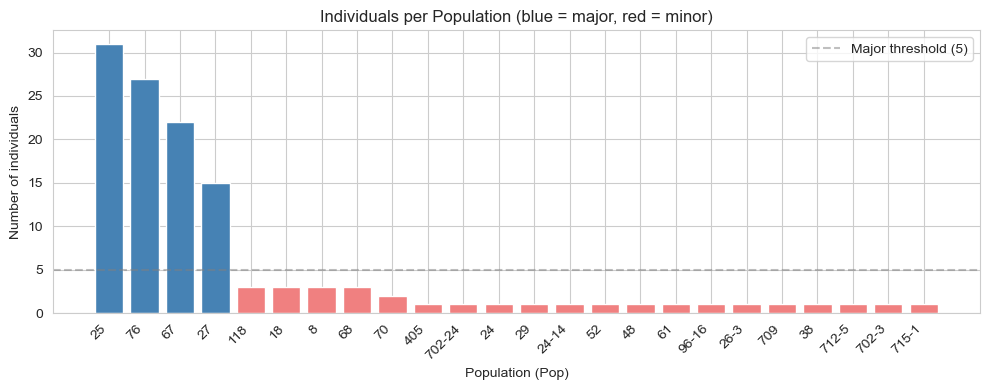

In [11]:
# --- Visualize population sizes ---
fig, ax = plt.subplots(figsize=(10, 4))
pops_sorted = pop_counts.index.tolist()
colors = ["steelblue" if c >= 5 else "lightcoral" for c in pop_counts.values]
ax.bar(range(len(pops_sorted)), pop_counts.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(pops_sorted)))
ax.set_xticklabels(pops_sorted, rotation=45, ha="right")
ax.set_xlabel("Population (Pop)")
ax.set_ylabel("Number of individuals")
ax.set_title("Individuals per Population (blue = major, red = minor)")
ax.axhline(y=5, color="gray", linestyle="--", alpha=0.5, label="Major threshold (5)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. EDA: Protein Prevalence

How many individuals carry each SRK protein? This informs allele rarity and crossing strategy.

Total protein columns: 94
Proteins detected in ingroup: 92
Singletons (1 individual only): 39 (42.4%)
Shared proteins (2+ individuals): 53

Top 10 most common proteins:
  SRK_protein_003: 12 individuals
  SRK_protein_004: 8 individuals
  SRK_protein_044: 7 individuals
  SRK_protein_022: 7 individuals
  SRK_protein_009: 7 individuals
  SRK_protein_059: 5 individuals
  SRK_protein_040: 5 individuals
  SRK_protein_057: 5 individuals
  SRK_protein_014: 4 individuals
  SRK_protein_045: 4 individuals


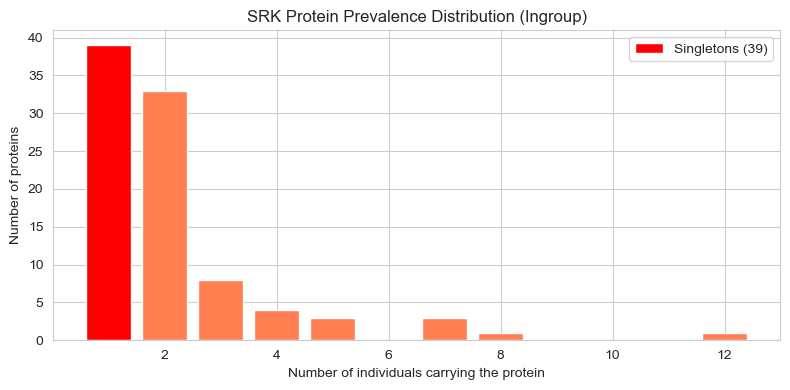

In [12]:
# Protein prevalence across ingroup individuals only
ingroup_geno = genotypes_filtered.set_index("Individual")[protein_columns]
protein_prevalence = ingroup_geno.sum(axis=0).astype(int).sort_values(ascending=False)

# Filter to detected proteins
detected_proteins = protein_prevalence[protein_prevalence > 0]
n_singletons = (detected_proteins == 1).sum()

print(f"Total protein columns: {len(protein_columns)}")
print(f"Proteins detected in ingroup: {len(detected_proteins)}")
print(f"Singletons (1 individual only): {n_singletons} ({100*n_singletons/len(detected_proteins):.1f}%)")
print(f"Shared proteins (2+ individuals): {len(detected_proteins) - n_singletons}")

print(f"\nTop 10 most common proteins:")
for prot_name, count in detected_proteins.head(10).items():
    print(f"  {prot_name}: {count} individuals")

# Prevalence histogram
fig, ax = plt.subplots(figsize=(8, 4))
prev_dist = detected_proteins.value_counts().sort_index()
ax.bar(prev_dist.index, prev_dist.values, color="coral", edgecolor="white")
if 1 in prev_dist.index:
    ax.bar([1], [prev_dist[1]], color="red", edgecolor="white", label=f"Singletons ({n_singletons})")
ax.set_xlabel("Number of individuals carrying the protein")
ax.set_ylabel("Number of proteins")
ax.set_title("SRK Protein Prevalence Distribution (Ingroup)")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Allele Frequencies

Compute allele frequencies from the assigned tetraploid genotypes (4 copies per individual). Compare overall frequencies to the NFDS equilibrium target (equal frequency for all alleles).

Distinct alleles in population: 92
NFDS target frequency (equal): 0.0109
Frequency variance: 0.000087
Frequency range: 0.0020 - 0.0685


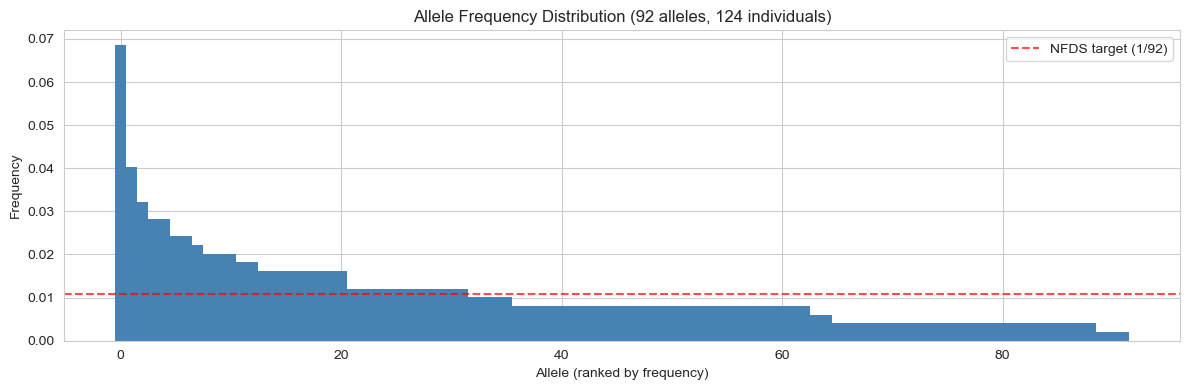

In [13]:
def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies from a list of genotype tuples."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))


# --- Overall allele frequencies ---
overall_freqs = allele_frequencies(population_genotypes, allele_pool)
nonzero_freqs = {a: f for a, f in overall_freqs.items() if f > 0}

target_freq = 1.0 / len(nonzero_freqs)  # NFDS equilibrium target
freq_variance = np.var(list(nonzero_freqs.values()))

print(f"Distinct alleles in population: {len(nonzero_freqs)}")
print(f"NFDS target frequency (equal): {target_freq:.4f}")
print(f"Frequency variance: {freq_variance:.6f}")
print(f"Frequency range: {min(nonzero_freqs.values()):.4f} - {max(nonzero_freqs.values()):.4f}")

# --- Plot ranked frequency distribution ---
freq_vals = sorted(nonzero_freqs.values(), reverse=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(freq_vals)), freq_vals, color="steelblue", edgecolor="none", width=1.0)
ax.axhline(y=target_freq, color="red", linestyle="--", alpha=0.7,
           label=f"NFDS target (1/{len(nonzero_freqs)})")
ax.set_xlabel("Allele (ranked by frequency)")
ax.set_ylabel("Frequency")
ax.set_title(f"Allele Frequency Distribution ({len(nonzero_freqs)} alleles, {len(population_genotypes)} individuals)")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Per-Population Allele Frequencies

Compare allele frequency distributions across populations. This reveals which alleles are shared vs. private to specific populations, and helps identify cross-population crossing opportunities.

In [14]:
# Identify core alleles (present in 2+ ingroup individuals) for cleaner visualization
core_protein_names = detected_proteins[detected_proteins >= 2].index.tolist()
core_allele_ids = sorted([name_to_id[p] for p in core_protein_names])
print(f"Core alleles (in 2+ individuals): {len(core_allele_ids)}")
print(f"Singleton alleles (excluded from heatmap): {n_singletons}\n")

# Build frequency matrix: populations x core alleles
# Only show populations with >= 2 individuals for meaningful frequencies
display_pops = [p for p in sorted(pop_populations.keys()) if len(pop_populations[p]) >= 2]
print(f"Populations with >= 2 individuals (shown in heatmap): {len(display_pops)}")

freq_matrix = np.zeros((len(display_pops), len(core_allele_ids)))
for pi, pop in enumerate(display_pops):
    pop_freqs = allele_frequencies(pop_populations[pop], allele_pool)
    for ai, a_id in enumerate(core_allele_ids):
        freq_matrix[pi, ai] = pop_freqs.get(a_id, 0.0)

# Per-population summary
print(f"\n{'Pop':<10} {'N':>4} {'Alleles':>8} {'Max freq':>10} {'Min freq':>10}")
print("-" * 45)
for pi, pop in enumerate(display_pops):
    pop_freqs = allele_frequencies(pop_populations[pop], allele_pool)
    nz = [f for f in pop_freqs.values() if f > 0]
    n_ind = len(pop_populations[pop])
    print(f"{pop:<10} {n_ind:>4} {len(nz):>8} {max(nz):>10.4f} {min(nz):>10.4f}")

Core alleles (in 2+ individuals): 53
Singleton alleles (excluded from heatmap): 39

Populations with >= 2 individuals (shown in heatmap): 9

Pop           N  Alleles   Max freq   Min freq
---------------------------------------------
118           3        4     0.3333     0.1667
18            3        3     0.3333     0.3333
25           31       26     0.1855     0.0081
27           15       17     0.1000     0.0333
67           22       20     0.1023     0.0114
68            3        2     0.6667     0.3333
70            2        1     1.0000     1.0000
76           27       23     0.1111     0.0093
8             3        4     0.3333     0.1667


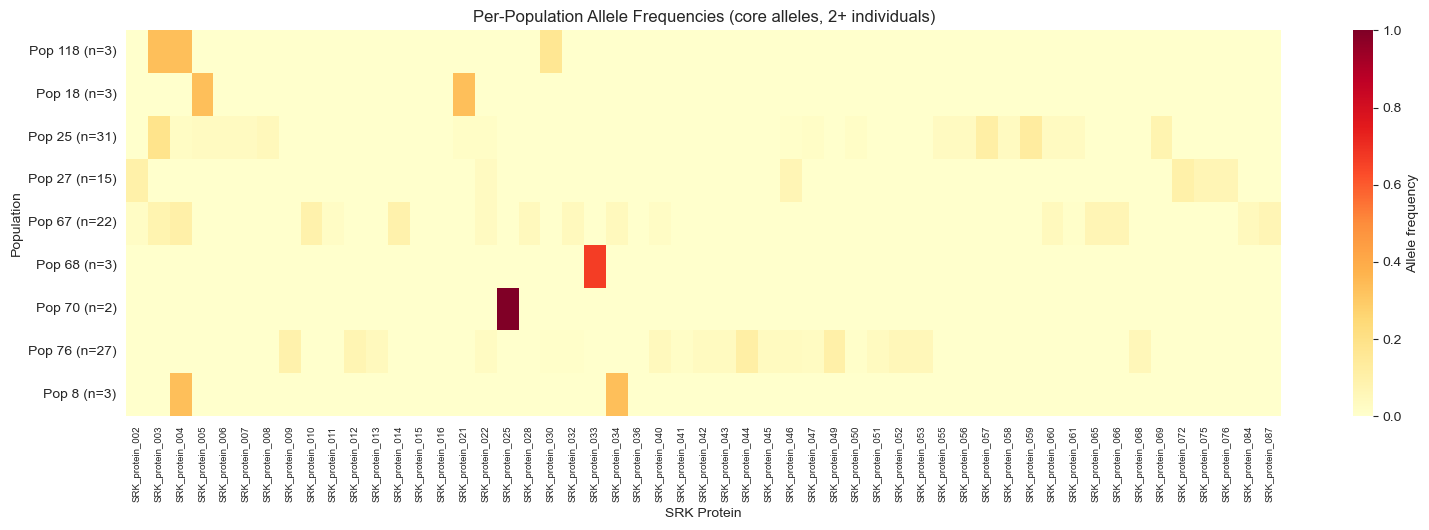

In [15]:
# Heatmap of per-population allele frequencies
fig, ax = plt.subplots(figsize=(max(14, len(core_allele_ids) * 0.3),
                                max(4, len(display_pops) * 0.6)))
sns.heatmap(
    freq_matrix,
    xticklabels=[id_to_name[a] for a in core_allele_ids],
    yticklabels=[f"Pop {p} (n={len(pop_populations[p])})" for p in display_pops],
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Allele frequency"},
)
ax.set_xlabel("SRK Protein")
ax.set_ylabel("Population")
ax.set_title("Per-Population Allele Frequencies (core alleles, 2+ individuals)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 12. Data Quality Summary

In [16]:
genotype_counts = zygosity_filtered["Genotype"].value_counts()

summary_data = {
    "Metric": [
        "Total individuals in revised data",
        "Ingroup individuals with genotypes",
        "Excluded (outgroup + no metadata)",
        "Distinct SRK proteins detected",
        "Singleton proteins (1 individual)",
        "Core proteins (2+ individuals)",
        "Unique populations (Pop)",
        "Major populations (>= 5 individuals)",
        "AAAA (homozygous) genotypes",
        "AABB (2-protein heterozygous) genotypes",
        "AABC (3-protein, read-resolved) genotypes",
        "ABCD (4-protein heterozygous) genotypes",
        "Genotypes requiring read-depth resolution",
        "Genotypes fully deterministic",
    ],
    "Value": [
        len(zygosity_df),
        len(assignments_df),
        len(zygosity_df) - len(assignments_df),
        len(detected_proteins),
        int(n_singletons),
        len(detected_proteins) - int(n_singletons),
        len(pop_populations),
        int((pop_counts >= 5).sum()),
        int(genotype_counts.get("AAAA", 0)),
        int(genotype_counts.get("AABB", 0)),
        int(genotype_counts.get("AABC", 0)),
        int(genotype_counts.get("ABCD", 0)),
        int(genotype_counts.get("AABC", 0)),
        len(assignments_df) - int(genotype_counts.get("AABC", 0)),
    ],
}

summary_table = pd.DataFrame(summary_data)
print("Data Quality Summary")
print("=" * 55)
print(summary_table.to_string(index=False))

Data Quality Summary
                                   Metric  Value
        Total individuals in revised data    128
       Ingroup individuals with genotypes    124
        Excluded (outgroup + no metadata)      4
           Distinct SRK proteins detected     92
        Singleton proteins (1 individual)     39
           Core proteins (2+ individuals)     53
                 Unique populations (Pop)     24
     Major populations (>= 5 individuals)      4
              AAAA (homozygous) genotypes     64
  AABB (2-protein heterozygous) genotypes     49
AABC (3-protein, read-resolved) genotypes      5
  ABCD (4-protein heterozygous) genotypes      6
Genotypes requiring read-depth resolution      5
            Genotypes fully deterministic    119


## 13. Export Data

Save the assigned population data for downstream notebooks (`06_real_analysis.ipynb` and others).

### Exported files

| File | Format | Contents |
|---|---|---|
| `data/population.pkl` | Pickle | Full population data dict (genotypes, mappings, pop groups) |
| `data/assigned_genotypes.tsv` | TSV | Human-readable genotype assignments with Pop |

In [17]:
# --- Build export data ---
export_data = {
    "population": population_genotypes,
    "individual_names": individual_names,
    "allele_pool": allele_pool,
    "name_to_id": name_to_id,
    "id_to_name": id_to_name,
    "pop_map": pop_map,              # individual -> Pop
    "pop_populations": pop_populations,  # Pop -> list of genotype tuples
    "pop_individuals": pop_individuals,  # Pop -> list of individual names
    "core_allele_ids": core_allele_ids,
    "assignments": assignments_df.to_dict(orient="records"),
}

# Save pickle
pkl_path = os.path.join(DATA_DIR, "population.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(export_data, f)
print(f"Saved pickle: {pkl_path}")

# Save human-readable TSV
tsv_rows = []
for i, (_, row) in enumerate(assignments_df.iterrows()):
    g = row["genotype"]
    int_g = population_genotypes[i]
    tsv_rows.append({
        "Individual": row["individual"],
        "Pop": row["pop"],
        "Genotype_Pattern": row["genotype_pattern"],
        "Protein_1": g[0],
        "Protein_2": g[1],
        "Protein_3": g[2],
        "Protein_4": g[3],
        "ID_1": int_g[0],
        "ID_2": int_g[1],
        "ID_3": int_g[2],
        "ID_4": int_g[3],
        "Method": row["method"].split(" (")[0],
    })

tsv_df = pd.DataFrame(tsv_rows)
tsv_path = os.path.join(DATA_DIR, "assigned_genotypes.tsv")
tsv_df.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved TSV: {tsv_path}")
print(f"\nFirst 10 rows:")
print(tsv_df.head(10).to_string(index=False))

Saved pickle: ../data/population.pkl
Saved TSV: ../data/assigned_genotypes.tsv

First 10 rows:
          Individual   Pop Genotype_Pattern       Protein_1       Protein_2       Protein_3       Protein_4  ID_1  ID_2  ID_3  ID_4           Method
Library001_barcode01    27             AABB SRK_protein_001 SRK_protein_001 SRK_protein_002 SRK_protein_002     1     1     2     2 heterozygous_2x2
Library001_barcode02    67             AABB SRK_protein_084 SRK_protein_084 SRK_protein_088 SRK_protein_088    84    84    88    88 heterozygous_2x2
Library001_barcode04 702-3             AAAA SRK_protein_016 SRK_protein_016 SRK_protein_016 SRK_protein_016    16    16    16    16    homozygous_4x
Library001_barcode05 712-5             AAAA SRK_protein_089 SRK_protein_089 SRK_protein_089 SRK_protein_089    89    89    89    89    homozygous_4x
Library001_barcode06    38             AAAA SRK_protein_090 SRK_protein_090 SRK_protein_090 SRK_protein_090    90    90    90    90    homozygous_4x
Library001_

In [18]:
def load_population(data_dir=None):
    """Convenience function to load assigned population data.

    Returns
    -------
    dict with keys:
        population : list[tuple] - assigned genotypes (integer IDs)
        individual_names : list[str] - individual names (parallel to population)
        allele_pool : list[int] - all allele IDs
        name_to_id : dict - protein name to integer ID
        id_to_name : dict - integer ID to protein name
        pop_map : dict - individual name to Pop
        pop_populations : dict - Pop to list of genotype tuples
        pop_individuals : dict - Pop to list of individual names
        core_allele_ids : list[int] - alleles present in 2+ individuals
        assignments : list[dict] - full assignment details per individual
    """
    if data_dir is None:
        data_dir = os.path.join("..", "data")
    pkl_path = os.path.join(data_dir, "population.pkl")
    with open(pkl_path, "rb") as f:
        return pickle.load(f)


# Verify round-trip
loaded = load_population(DATA_DIR)
assert loaded["population"] == population_genotypes
assert loaded["allele_pool"] == allele_pool
assert loaded["pop_map"] == pop_map
print(f"Round-trip verification passed.")
print(f"  {len(loaded['population'])} genotypes")
print(f"  {len(loaded['allele_pool'])} alleles")
print(f"  {len(loaded['pop_populations'])} populations")
print(f"\nTo load in other notebooks:")
print("  from pathlib import Path")
print("  import pickle")
print("  data = pickle.load(open(Path('..') / 'data' / 'population.pkl', 'rb'))")

Round-trip verification passed.
  124 genotypes
  94 alleles
  24 populations

To load in other notebooks:
  from pathlib import Path
  import pickle
  data = pickle.load(open(Path('..') / 'data' / 'population.pkl', 'rb'))
